# Time Series

Выполнил: Немкова Анастасия Романовна

Описание столбцов: 
* `Store` - ID магазина.
* `Date` - дата на момент фиксации фич.
* `Weekly_Sales` - продажи за неделю.
* `Temperature` - средняя температура за неделю в городе расположения магазина(в градусах Фарингейта)
* `Fuel_Price` - цена топлива в данном регионе.
* `CPI` - индекс потребительских цен
* `Unemployment` - уровень безработици в регионе.

Цель - предсказать `Weekly_Sales` на 4 измерения вперед(на месяц).

Порог прохождения лабораторки - MAPE(%) - 10% (Score on leaderboard < 0.1)

In [740]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from pylab import rcParams
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm


In [741]:
TRAIN_PATH = '/home/arnemkova/ML_labs/lab3/train.csv'
TEST_PATH = '/home/arnemkova/ML_labs/lab3/test.csv'

In [742]:
train_df = pd.read_csv(TRAIN_PATH, index_col=["Date"], parse_dates=["Date"])
test_df = pd.read_csv(TEST_PATH, index_col=["Date"], parse_dates=["Date"])
train_df.head()

,Store,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,
2010-01-10,1,1453329.50,71.89,2.603,211.671989,7.838
2010-02-04,1,1594968.28,62.27,2.719,210.820450,7.808
2010-02-07,1,1492418.14,80.91,2.669,211.223533,7.787
2010-02-19,1,1611968.17,39.93,2.514,211.289143,8.106
2010-02-26,1,1409727.59,46.63,2.561,211.319643,8.106


In [743]:
print(train_df.isnull().sum())
print(train_df.duplicated().sum())

Store           0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64
0


In [744]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6255 entries, 2010-01-10 to 2012-10-08
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6255 non-null   int64  
 1   Weekly_Sales  6255 non-null   float64
 2   Temperature   6255 non-null   float64
 3   Fuel_Price    6255 non-null   float64
 4   CPI           6255 non-null   float64
 5   Unemployment  6255 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 342.1 KB


Посмотрим на выбросы таргета

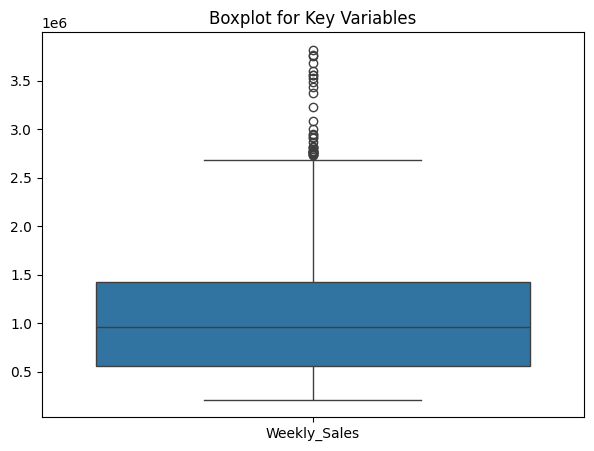

In [745]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df[['Weekly_Sales']])
plt.title('Boxplot for Key Variables')
plt.show()

In [746]:
Q1 = train_df["Weekly_Sales"].quantile(0.25)
Q3 = train_df["Weekly_Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


train_df = train_df[(train_df["Weekly_Sales"] >= lower_bound) & (train_df["Weekly_Sales"] <= upper_bound)]

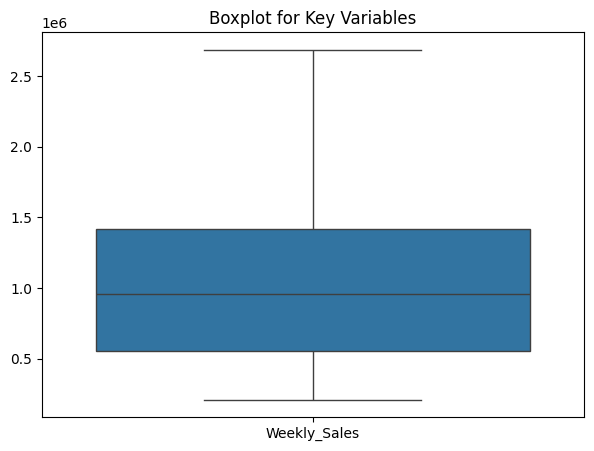

In [747]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=train_df[['Weekly_Sales']])
plt.title('Boxplot for Key Variables')
plt.show()

In [748]:
# train_df = train_df.groupby("Store").resample("W").mean().interpolate()
# train_df = train_df.drop(columns=['Store'], axis=1)
# train_df = train_df.reset_index(level="Store")
# train_df.interpolate(method='linear', inplace=True)
# train_df.head()


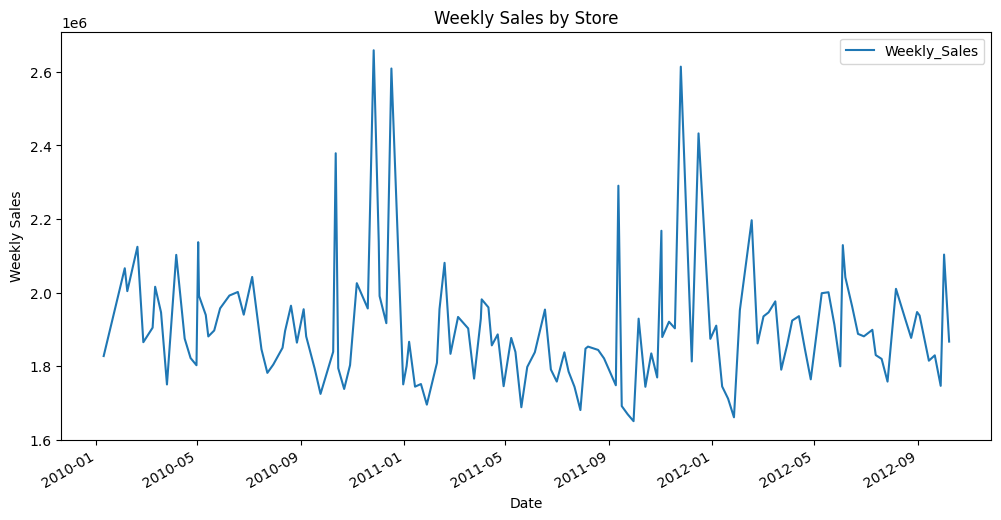

In [749]:
plt.figure(figsize=(12, 6))
train_df[train_df['Store'] == 2]['Weekly_Sales'].plot()
plt.title("Weekly Sales by Store")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()

Преобразуем дату

In [750]:
def add_time_features(df):
    df['Weekday'] = df.index.weekday 
    df['Month'] = df.index.month
    df['Year'] = df.index.year
    df['Week'] = df.index.isocalendar().week 
    return df

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)


In [751]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6221 entries, 2010-01-10 to 2012-10-08
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6221 non-null   int64  
 1   Weekly_Sales  6221 non-null   float64
 2   Temperature   6221 non-null   float64
 3   Fuel_Price    6221 non-null   float64
 4   CPI           6221 non-null   float64
 5   Unemployment  6221 non-null   float64
 6   Weekday       6221 non-null   int32  
 7   Month         6221 non-null   int32  
 8   Year          6221 non-null   int32  
 9   Week          6221 non-null   UInt32 
dtypes: UInt32(1), float64(5), int32(3), int64(1)
memory usage: 443.5 KB


Посторим график распределения продаж

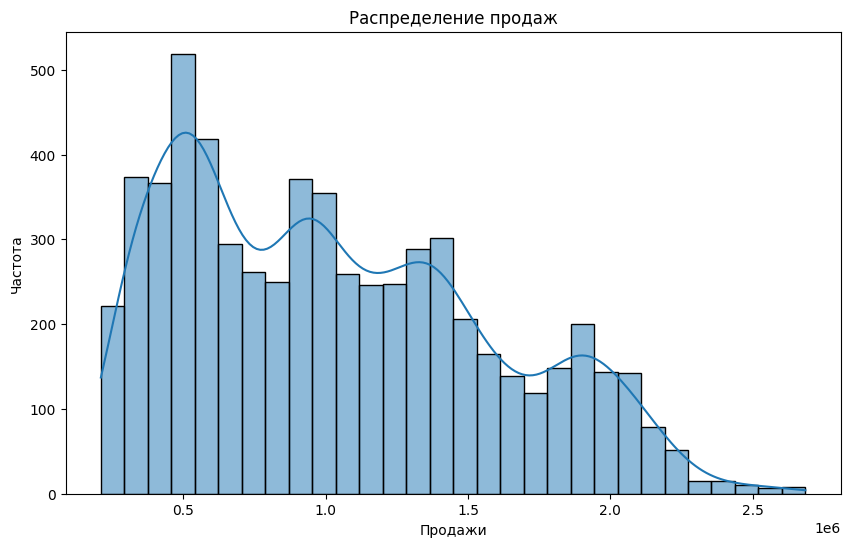

In [752]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df["Weekly_Sales"], bins=30, kde=True)
plt.title("Распределение продаж")
plt.xlabel("Продажи")
plt.ylabel("Частота")
plt.show()

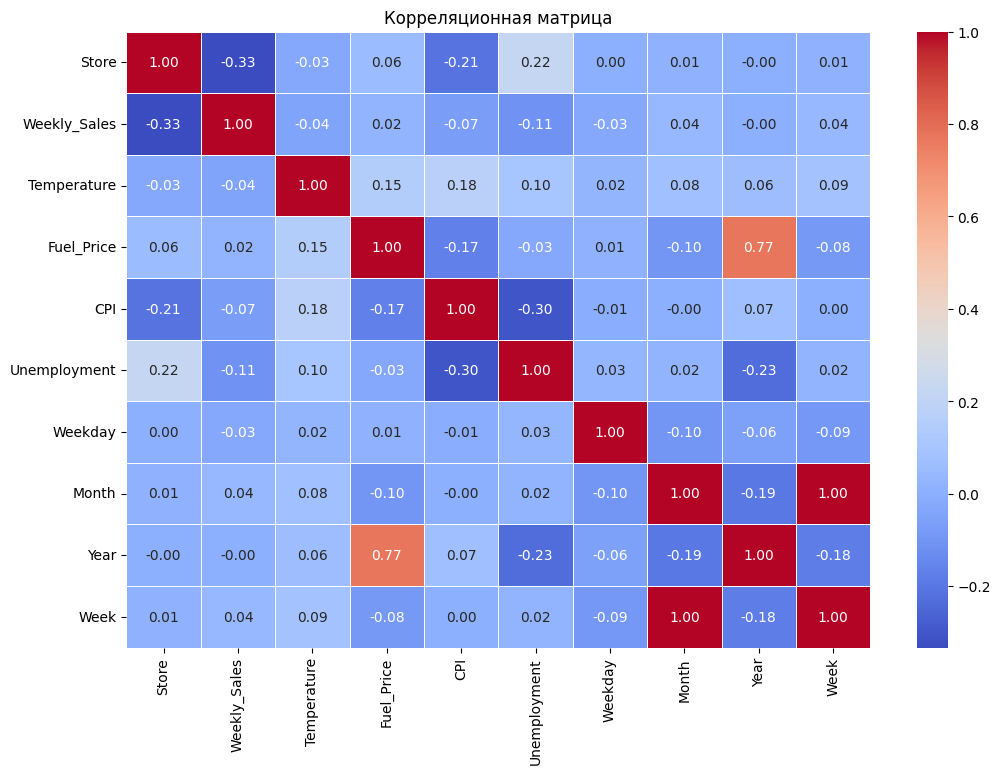

In [753]:
correlation_matrix = train_df.corr()


plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица')
plt.show()

Посмотрим на тренд, сезонность и случайные колебания

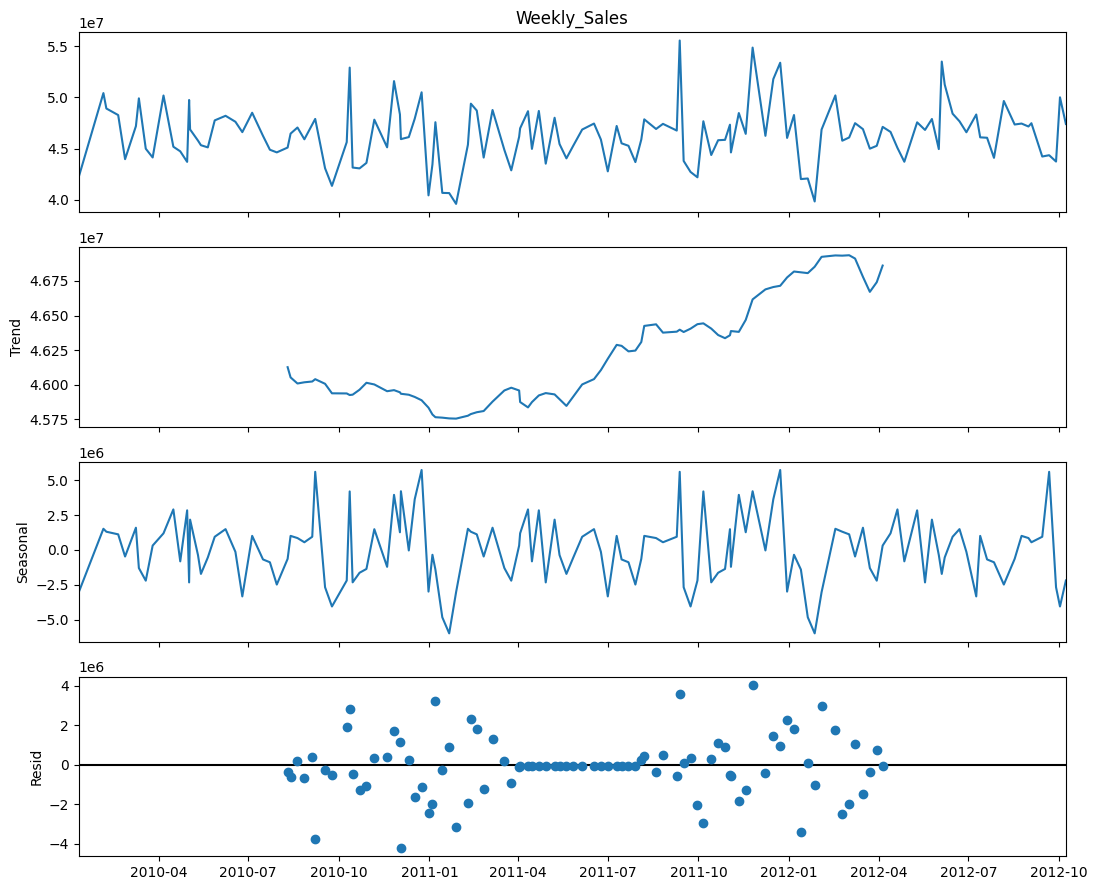

In [754]:
weekly_sales = train_df.groupby('Date')['Weekly_Sales'].sum()

rcParams['figure.figsize'] = 11, 9

decompose = seasonal_decompose(weekly_sales, model='additive', period=52)
decompose.plot()

plt.show()

Тест Дики-Фуллера для оценки стационарности

In [755]:
grouped = train_df.groupby('Store')

def adf_test(series):
    result = adfuller(series)
    return result[1]

adf_results = grouped['Weekly_Sales'].apply(adf_test)

non_stationary_stores = adf_results[adf_results > 0.05]

print(non_stationary_stores)

Store
4     0.623952
14    0.574698
33    0.214637
36    0.758448
38    0.866352
43    0.187213
44    0.927671
Name: Weekly_Sales, dtype: float64


Итого получаем, критерий Дики-Фуллера не отвергает гипотезу нестационарности для магазинов 4, 14, 33, 36, 38 и 43. И также прослеживается тренд

Сделаем дифференцирование и проверим еще раз

In [756]:
def differentiate_with_shift_inplace(df, shift=1):
    df['Diff_Weekly_Sales'] = df.groupby('Store')['Weekly_Sales'].transform(lambda x: x - x.shift(shift))

differentiate_with_shift_inplace(train_df, shift=1)

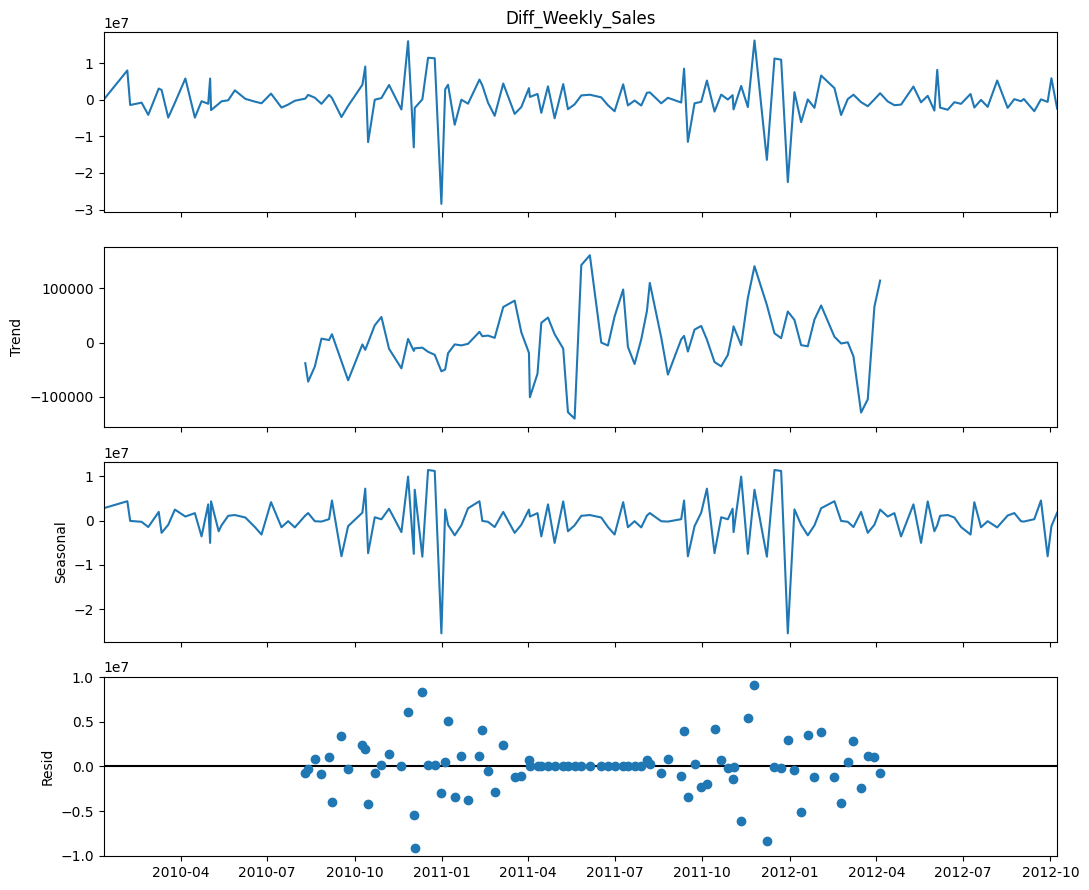

Series([], Name: Diff_Weekly_Sales, dtype: float64)


In [757]:
weekly_sales = train_df.groupby('Date')['Diff_Weekly_Sales'].apply(lambda x: x.iloc[1:].sum())
rcParams['figure.figsize'] = 11, 9

decompose = seasonal_decompose(weekly_sales, model='additive', period=52)
decompose.plot()

plt.show()

grouped = train_df.groupby('Store')

def adf_test(series):
    result = adfuller(series)
    return result[1]

adf_results = grouped['Diff_Weekly_Sales'].apply(lambda x: adf_test(x[1:]))

non_stationary_stores = adf_results[adf_results > 0.05]

print(non_stationary_stores)

In [758]:
# store_data = train_df[train_df['Store'] == 1]['Differenced_Weekly_Sales'][1:]

# fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# sm.graphics.tsa.plot_acf(store_data.values, lags=50, ax=axes[0])
# axes[0].set_title('ACF (Autocorrelation Function)')

# sm.graphics.tsa.plot_pacf(store_data.values, lags=50, ax=axes[1])
# axes[1].set_title('PACF (Partial Autocorrelation Function)')

# plt.tight_layout()
# plt.show()

In [759]:
# features_to_plot = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'MA', 'ES']

# plt.figure(figsize=(15, 10))

# for i, feature in enumerate(features_to_plot, 1):
#     plt.subplot(3, 3, i)
#     sns.histplot(train_df[feature], bins=30, kde=True)
#     plt.title(f'Зависимость {feature} от Weekly_Sales для магазинов')
#     plt.xlabel(feature)
#     plt.ylabel('Weekly_Sales')

# plt.tight_layout()
# plt.show()


In [760]:
features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Weekday', 'Month', 'Year', 'Week']

all_y_true = []
all_y_pred = []
models = {} 

for store_id in train_df['Store'].unique():

    store_data = train_df[train_df['Store'] == store_id]
    
    X = store_data[features]
    y = store_data['Weekly_Sales']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    models[store_id] = model
    
    y_pred = model.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # графики
    # y_pred_full = np.concatenate([y_train.values, y_pred])
    # y_test_full = np.concatenate([y_train.values, y_test.values])
    # plt.figure(figsize=(15, 7))
    # plt.plot(y_pred_full, "r", label="Prediction")
    # plt.plot(y_test_full, label="Test")
    # plt.plot(y_train.values, label="Train")
    # plt.legend(loc="best")
    # plt.title(f"Store {store_id} - Mean Absolute Percentage Error: {mean_absolute_percentage_error(y_pred, y_test)}")
    # plt.grid(True)
    # plt.show()

mape = mean_absolute_percentage_error(all_y_true, all_y_pred)
print(f"MAPE: {mape}")

MAPE: 0.06656527594022771


# Submit

In [761]:
predictions = []

for store_id, store_data in test_df.groupby('Store'):
    model = models.get(store_id)
    
    X_test = store_data[features]
    
    y_pred = model.predict(X_test)
    
    predictions.extend(y_pred)

data = {
    "source_attractiveness": predictions
}
submit = pd.DataFrame(data)
submit.to_csv('submission.csv', index_label="ID")